In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def simulate_investment(initial_investment, fixed_rate, mean_return, std_dev, proportion_risky, years, simulations):
    proportion_fixed = 1 - proportion_risky
    results = []
    for _ in range(simulations):
        portfolio_value = initial_investment
        for _ in range(years):
            random_return = np.exp(np.random.normal(mean_return, std_dev)) - 1
            portfolio_return = (proportion_fixed * fixed_rate) + ((1 - proportion_fixed) * random_return)
            portfolio_value *= (1 + portfolio_return)
        results.append(portfolio_value)
    mean_end_value = np.mean(results)
    theoretical_return_single_period = proportion_fixed * fixed_rate + proportion_risky * (np.exp(mean_return + 0.5 * std_dev**2) - 1)
    theoretical_end_value   = (1 + theoretical_return_single_period) ** years * initial_investment
    return theoretical_return_single_period, theoretical_end_value, mean_end_value

In [8]:
def simulate_investment_test(initial_investment, fixed_rate, mean_return, std_dev, proportion_risky, years, x):
    proportion_fixed = 1 - proportion_risky
    yearly_values = []
    portfolio_value = initial_investment
    for i in range(years):
        random_return = np.exp(x[i]) - 1
        portfolio_return = (proportion_fixed * fixed_rate) + ((1 - proportion_fixed) * random_return)
        portfolio_value *= (1 + portfolio_return)
        yearly_values.append(portfolio_value)
    return portfolio_value, yearly_values

In [6]:
print(x)

[-0.72394237 -0.39302108  0.67980571  0.42208487 -0.00795292  0.01950439
 -0.23395577  0.35696796  0.48373894  0.19278964 -0.72400351  0.36501696
  0.12367446 -0.13199871  0.25095412 -0.13843789 -0.21243842 -0.09154984
  0.34296608  0.26464561 -0.3602471  -0.01577296 -0.45939893  0.04780681]


In [10]:
#x = np.random.normal(0.04, 0.4, 24)
v=simulate_investment_test(1, 0.05, 0.04, 0.4, 0.5, 24, x)
print(v[0])
print(v[1])

2.7350478578483233
[0.7674185381763959, 0.6619040600583597, 1.000631564483452, 1.2883821608236654, 1.3154888304405221, 1.3613308830831314, 1.2533751799657138, 1.5535523209064384, 2.0756454221316, 2.3482063879898143, 1.8020223117622791, 2.2440029218019903, 2.447811588377461, 2.3576612851986627, 2.7528655746402793, 2.643738312429985, 2.456839376818022, 2.4107930938443687, 2.9642159184308503, 3.4873542861377453, 3.047082697726732, 3.099417536075788, 2.606088213097616, 2.7350478578483233]


In [5]:
#save v to investment_output.txt
with open("investment_output.txt", "w") as f:
    f.write(str(x) + "\n")
    f.write(str(v))
# Example usage


In [5]:
a=simulate_investment(1, 0.0025, 0.004, 0.05, 0.5, 24, 10000)
print(a) 

(0.00388190269943725, 1.0974456042155833, 1.0961001993297743)


In [12]:
a_values = []
proportions = np.linspace(0, 1, 11)
for p in proportions:
    _, theor_value, mean_end_value = simulate_investment(1, 0.05, 0.04, 0.4, p, 24, 500)
    a_values.append([theor_value, mean_end_value])

In [13]:
a_values

[[3.225099943713703, 3.2250999437137033],
 [3.8475982065286565, 3.8673681545597347],
 [4.584339130145246, 4.668389811446554],
 [5.45522111835902, 5.629872922021712],
 [6.4834253083996725, 6.340245396518512],
 [7.69592739423737, 8.239874706285207],
 [9.1240846831018, 9.173324776908592],
 [10.804308782603584, 9.667266016609872],
 [12.778835662782265, 10.021483431209976],
 [15.09660634733957, 11.6656493241331],
 [17.814273179612222, 18.380265903662526]]

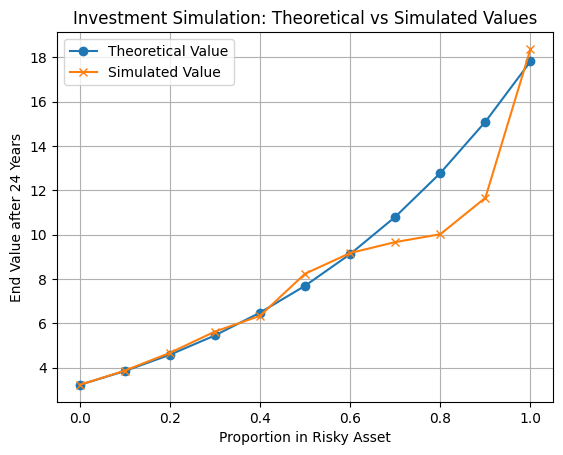

In [14]:
plot_proportions = proportions
theoretical_values = [v[0] for v in a_values]
simulated_values = [v[1] for v in a_values]
plt.plot(plot_proportions, theoretical_values, label='Theoretical Value', marker='o')
plt.plot(plot_proportions, simulated_values, label='Simulated Value', marker='x')
plt.xlabel('Proportion in Risky Asset')
plt.ylabel('End Value after 24 Years')
plt.title('Investment Simulation: Theoretical vs Simulated Values')
plt.legend()
plt.grid()
plt.show()
